Dataset loaded with 100000 rows and 54 columns.

Missing Values (greater than 0):
alcohol_freq    30083
dtype: int64


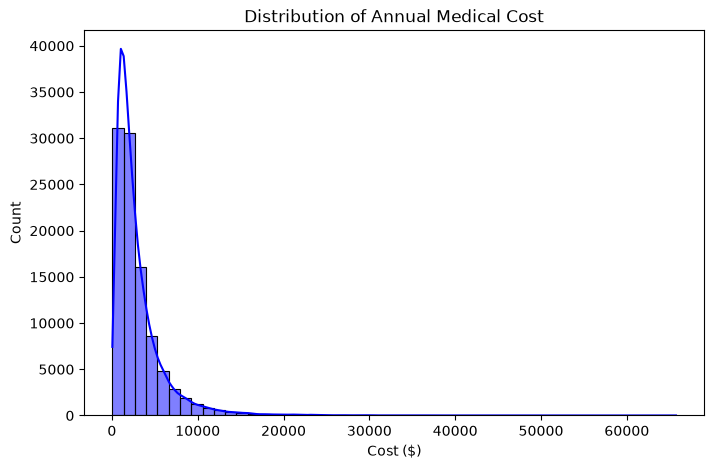


Top 10 numerical factors driving medical costs:
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
Name: annual_medical_cost, dtype: float64


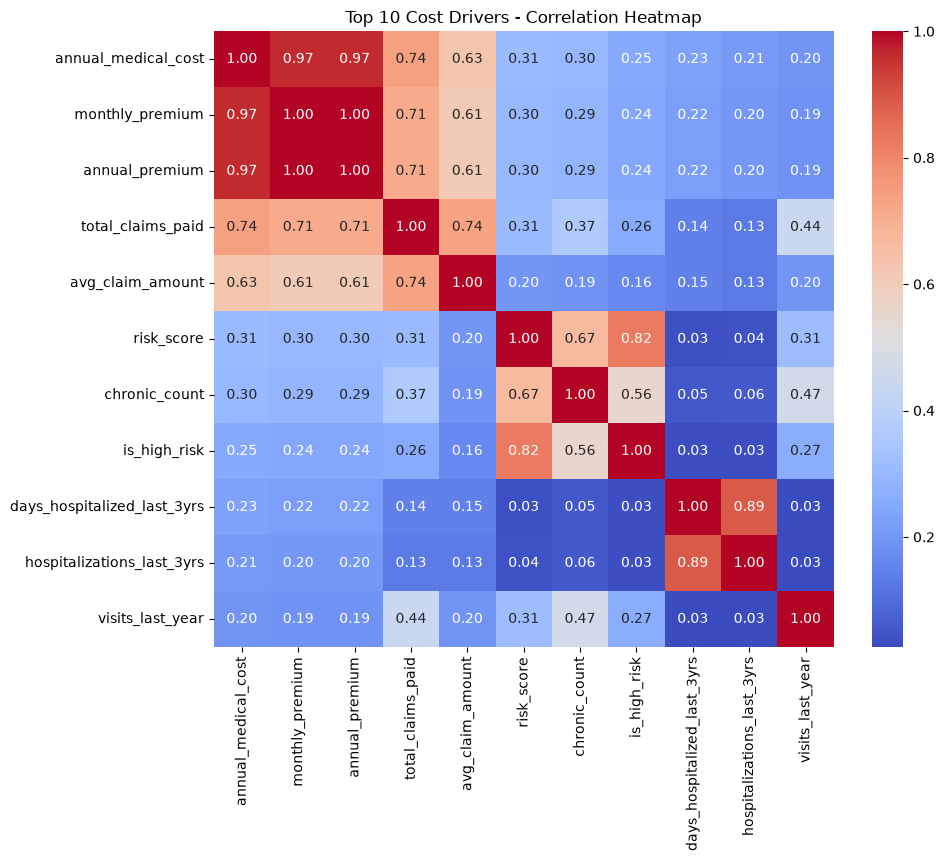

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
df = pd.read_csv('../data/raw/medical_insurance.csv')

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

# 2. View missing values
missing_data = df.isnull().sum()
print("\nMissing Values (greater than 0):")
print(missing_data[missing_data > 0])

# 3. Plot the distribution of the target variable (annual_medical_cost)
plt.figure(figsize=(8, 5))
sns.histplot(df['annual_medical_cost'], bins=50, kde=True, color='blue')
plt.title('Distribution of Annual Medical Cost')
plt.xlabel('Cost ($)')
plt.show()

# 4. Find the top 10 numerical features most correlated with medical cost
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['annual_medical_cost'].sort_values(ascending=False)

print("\nTop 10 numerical factors driving medical costs:")
print(correlations.head(11)[1:]) # Skip the first one since it's the cost correlating with itself

# 5. Plot a correlation heatmap of those top features
top_features = correlations.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Cost Drivers - Correlation Heatmap')
plt.show()